In [4]:
import json
import os
METRICS = ['train_hard_loss', 'train_soft_loss', 'train_acc','test_loss', 'test_acc']
def get_metrics(path):
    if not os.path.exists(path):
        # print(f"Error: File not found at path '{path}'.")
        return None
    with open(path, 'r') as f:
        data = json.load(f)
    return tuple(data[metric] for metric in METRICS)

def populate_dict(path):
    if get_metrics(path) == None:
        return None
    return dict(zip(METRICS, get_metrics(path)))

In [22]:
import numpy as np

RUNS = 1 
NOISE_STDS = [f'{noise_std:.2f}' for noise_std in np.arange(0, 1.667, 0.333)]
TARGETS = ['student', 'teacher', 'both']
DATASETS = ['TinyImageNet', 'Cifar100']

skip_counter = 0
counter = 0
things = {}
for dataset in DATASETS:
    things[dataset] = {}
    for target in TARGETS:
        things[dataset][target] = {}
        for noise_std in NOISE_STDS:
            things[dataset][target][noise_std] = {}
            for run in range(RUNS):
                path = f'experiments-2/{dataset}/{target}/std{noise_std}/{run}/metrics.json'
                if populate_dict(path) == None:
                    skip_counter += 1
                    continue
                counter += 1
                things[dataset][target][noise_std][run] = populate_dict(path)
print(skip_counter, counter)

0 36


In [23]:
def visualize_structure(things, max_depth=4):
    def recurse(level, indent=0):
        if indent >= max_depth:
            return  # stop at max depth
        if isinstance(level, dict):
            for key in level:
                print('  ' * indent + f"- {key}")
                recurse(level[key], indent + 1)

    print("Structure of 'things':")
    recurse(things)

visualize_structure(things)

Structure of 'things':
- TinyImageNet
  - student
    - 0.00
      - 0
    - 0.33
      - 0
    - 0.67
      - 0
    - 1.00
      - 0
    - 1.33
      - 0
    - 1.67
      - 0
  - teacher
    - 0.00
      - 0
    - 0.33
      - 0
    - 0.67
      - 0
    - 1.00
      - 0
    - 1.33
      - 0
    - 1.67
      - 0
  - both
    - 0.00
      - 0
    - 0.33
      - 0
    - 0.67
      - 0
    - 1.00
      - 0
    - 1.33
      - 0
    - 1.67
      - 0
- Cifar100
  - student
    - 0.00
      - 0
    - 0.33
      - 0
    - 0.67
      - 0
    - 1.00
      - 0
    - 1.33
      - 0
    - 1.67
      - 0
  - teacher
    - 0.00
      - 0
    - 0.33
      - 0
    - 0.67
      - 0
    - 1.00
      - 0
    - 1.33
      - 0
    - 1.67
      - 0
  - both
    - 0.00
      - 0
    - 0.33
      - 0
    - 0.67
      - 0
    - 1.00
      - 0
    - 1.33
      - 0
    - 1.67
      - 0


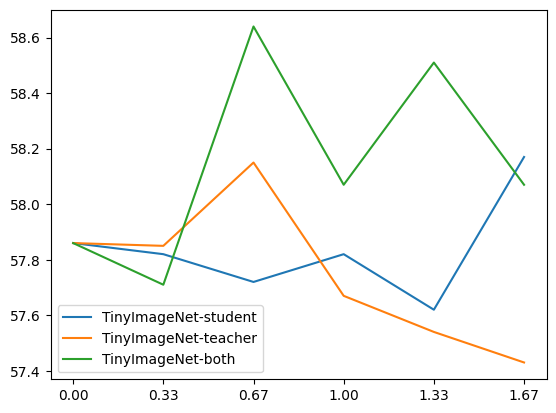

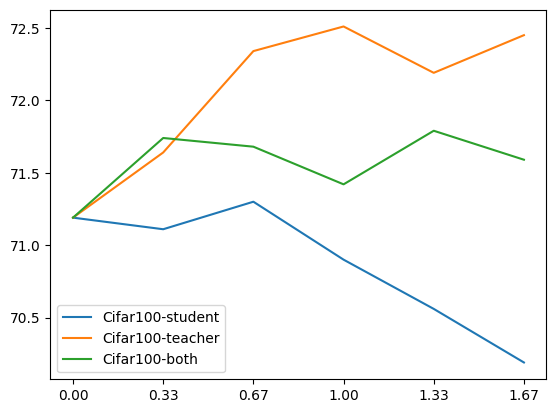

When noise std == 0 then change noise injection target has no effect


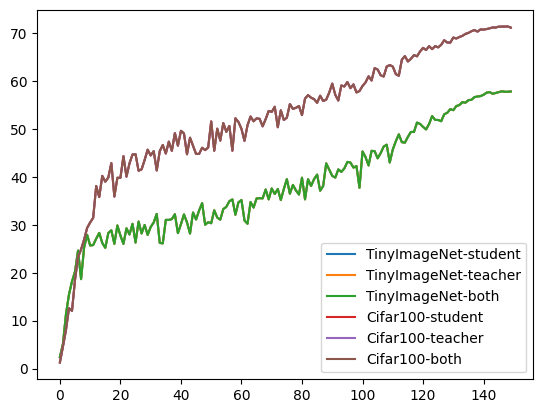

Effect noise-injection target has
TinyImageNet


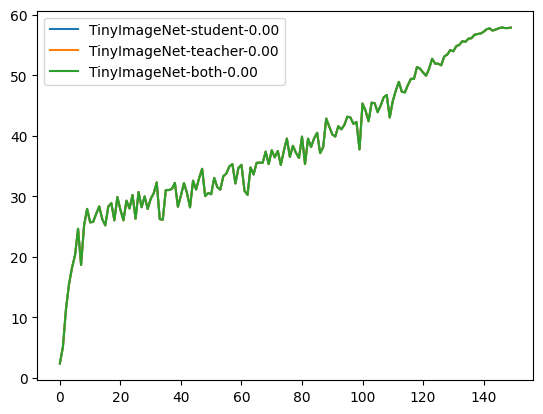

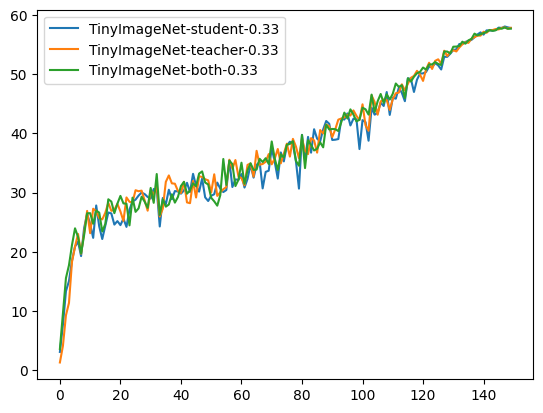

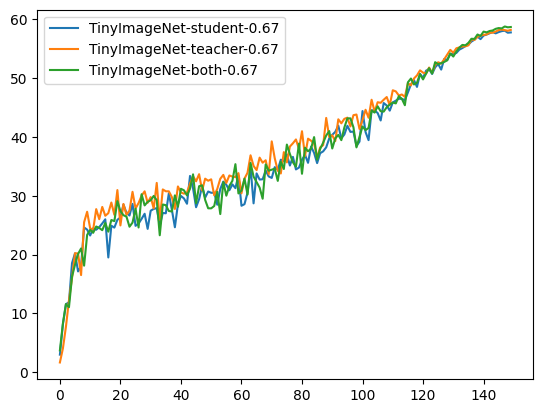

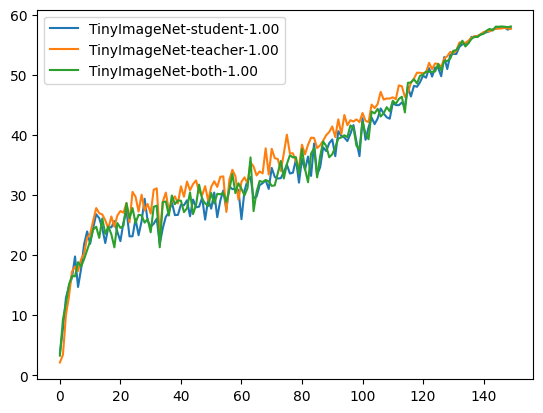

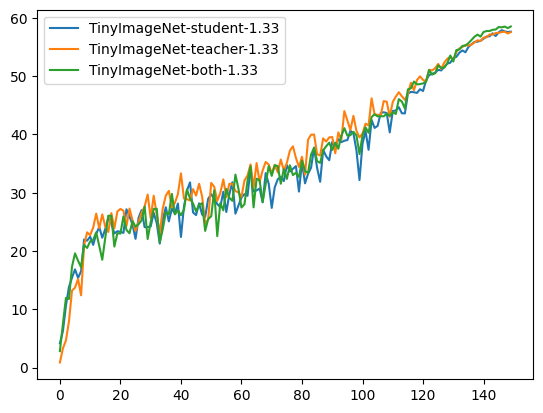

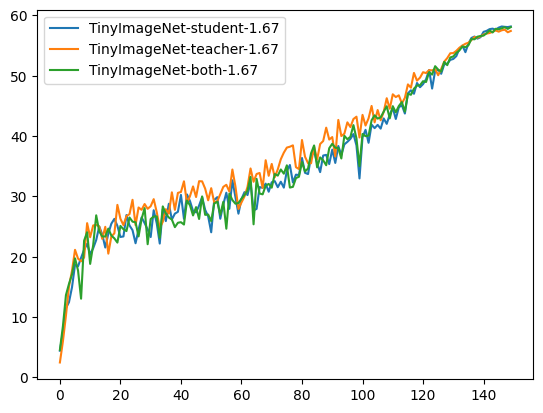

Cifar100


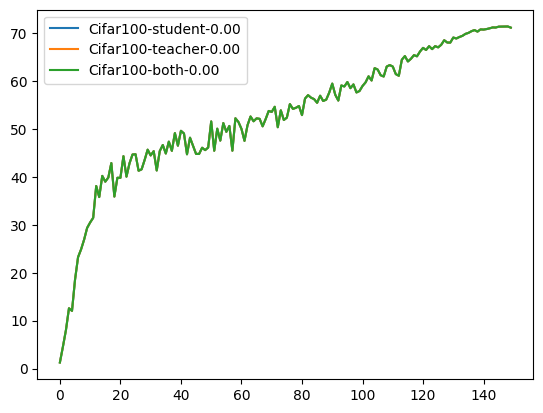

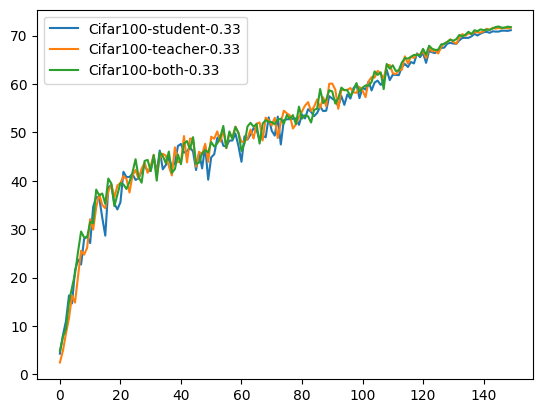

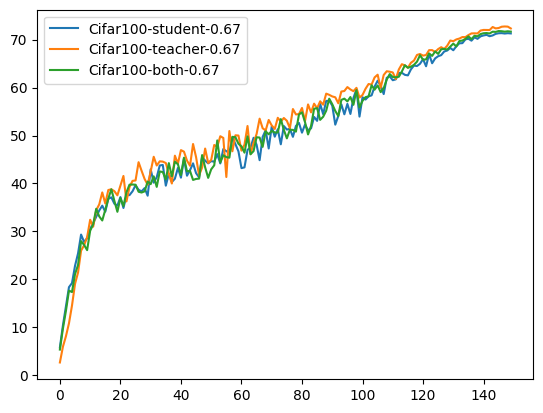

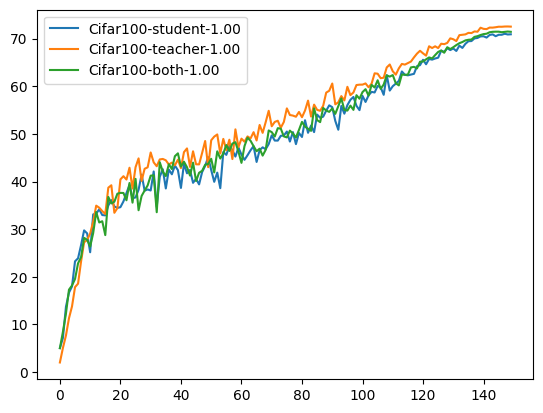

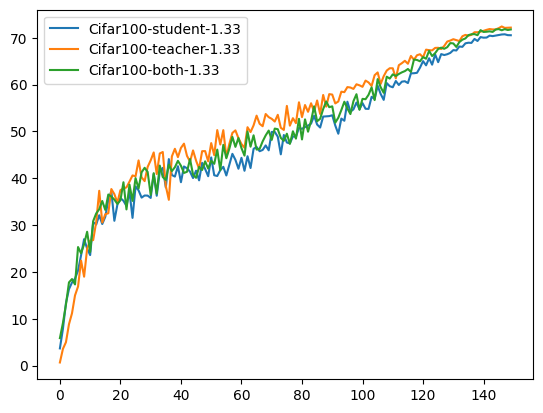

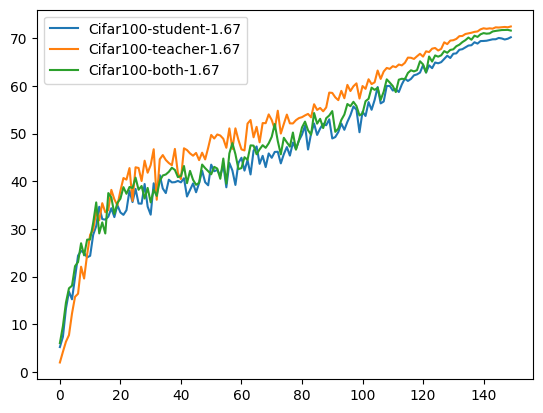

In [45]:
# things[dataset][target][noise_std][run]

import matplotlib.pyplot as plt
for dataset in DATASETS:
    for target in TARGETS:
        x   = np.asarray([std for std in NOISE_STDS]) #, dtype=float) 
        y   = np.asarray([things[dataset][target][std][0]['test_acc'][-1] for std in NOISE_STDS], dtype=float)
        # err = np.asarray([things[target][std]['test_acc']['std'] for std in STDS], dtype=float)
        plt.plot(x, y, label=f'{dataset}-{target}')
        # plt.fill_between(x, y-err, y+err, alpha=0.5)   # element-wise OK now

    plt.xticks(NOISE_STDS)

    plt.legend()
    plt.show()


print("When noise std == 0 then change noise injection target has no effect")
for dataset in DATASETS:
    for target in TARGETS:
        std = NOISE_STDS[0]
        accuracies = things[dataset][target][std][0]['test_acc']
        plt.plot(np.arange(150), accuracies, label=f'{dataset}-{target}')
plt.legend()
plt.show()

print('Effect noise-injection target has')
for dataset in DATASETS:
    print(dataset)
    for std in NOISE_STDS:
        for target in TARGETS:
            accuracies = things[dataset][target][std][0]['test_acc']
            plt.plot(np.arange(150), accuracies, label=f'{dataset}-{target}-{std}')
        plt.legend()
        plt.show()
